### Importing required libraries

In [ ]:
!pip install gensim
!pip install --upgrade gensim numpy
!pip install tensorflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import gensim
from gensim import corpora
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt_tab to C:\Users\Care
[nltk_data]     Pix\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Care
[nltk_data]     Pix\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Care
[nltk_data]     Pix\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Task 1 :

### Data Exploration and Preprocessing

In [3]:
df = pd.read_csv("Imdb - data_imdb.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
#Checking datatype in each available column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
# Shape of dataset

print("Rows, Columns:", df.shape)

Rows, Columns: (50000, 2)


In [6]:
# Check class distribution

df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [7]:
# Check for missing values

df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [8]:
#Checking types of unique vales available in dataset

df['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

In [9]:
#Creating a new column for review length

df['review_length'] = df['review'].apply(len)

#Using describe function
df['review_length'].describe()

count    50000.000000
mean      1309.367720
std        989.759532
min          7.000000
25%        699.000000
50%        970.000000
75%       1590.000000
max      13704.000000
Name: review_length, dtype: float64

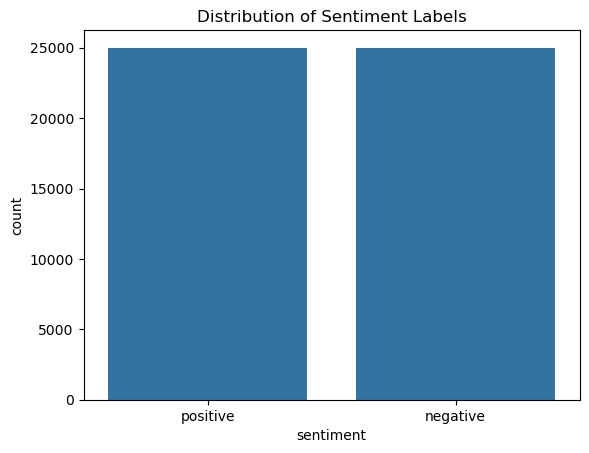

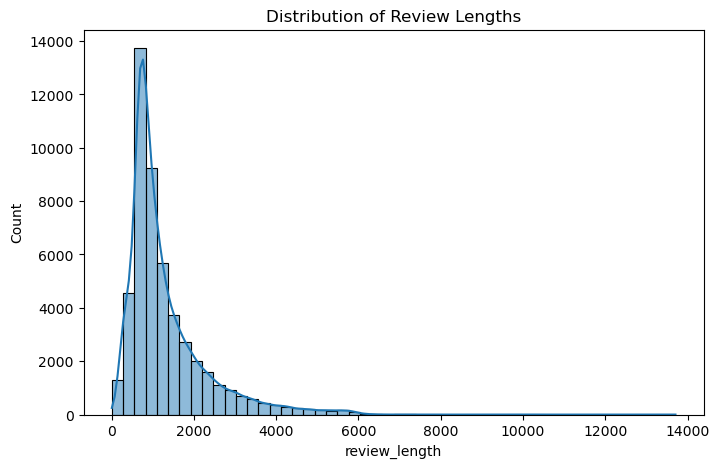

In [10]:
#Using visualization to check distribution of available sentiments
sns.countplot(x=df['sentiment'])
plt.title("Distribution of Sentiment Labels")
plt.show()

#Using visualization to check review length distribution
plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Distribution of Review Lengths")
plt.show()


Findings :

- The dataset contains two classes which are 'Positive' and 'Negative' and both the classes are almost perfectly balanced.
- Hence Classifier model won’t be biased towards one sentiment.
- The distribution is right-skewed indicating many short, medium reviews and fewer long reviews.

#### Data Preprocessing

In [11]:
stop_words = set(stopwords.words('english'))

#Since it is Sentiment Analyzer, I will use Lemmatization
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    #To Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    #To remove non-letter characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    #COnverting to lowercase
    text = text.lower()
    #Tokenization
    tokens = word_tokenize(text)
    #Removing stopwords and lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [12]:
df['cleaned_review'] = df['review'].apply(preprocess_text)
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


##### Using WordCloud for visualization of postive,negative and overall reviews.

In [ ]:
!pip install wordcloud

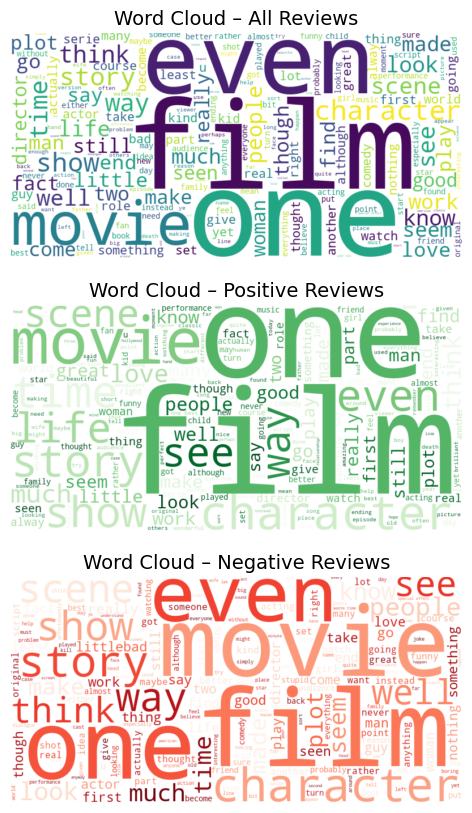

In [13]:
from wordcloud import WordCloud

#Combination of all reviews

overall_text = " ".join(df['cleaned_review'])

#For positive and negative reviews

positive_text = " ".join(df[df['sentiment'] == 'positive']['cleaned_review'])
negative_text = " ".join(df[df['sentiment'] == 'negative']['cleaned_review'])

#Creating word clouds

overall_wc = WordCloud(width=800, height=400, background_color='white').generate(overall_text)
positive_wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
negative_wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

#Plotting

plt.figure(figsize=(18,10))
plt.subplot(3,1,1)
plt.imshow(overall_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud – All Reviews", fontsize=14)
plt.subplot(3,1,2)
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud – Positive Reviews", fontsize=14)
plt.subplot(3,1,3)
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud – Negative Reviews", fontsize=14)
plt.show()

## Task 2 :

### Feature Engineering

In [14]:
le = LabelEncoder()

#Training and Test Split

X=df['cleaned_review']
y=le.fit_transform(df['sentiment'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Creating BoW model

bow = CountVectorizer(max_features = 5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [16]:
# Creating TF-IDF model

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [17]:
# Creating Word2Vec Model

tokenized_reviews = [review.split() for review in df['cleaned_review']]

# Training Word2Vec model
w2v_model = Word2Vec(sentences = tokenized_reviews, vector_size = 100, window = 5, min_count = 2, workers = 4, sg = 1)

# Function for creating average Word2Vec vector for each review
def get_vector(tokens):
    vec = np.zeros(100)
    count = 0
    for word in tokens:
        if word in w2v_model.wv:
            vec += w2v_model.wv[word]
            count += 1
    return vec / count if count > 0 else vec

df['review_vector'] = [get_vector(tokens) for tokens in tokenized_reviews]
df[['cleaned_review', 'review_vector']].head()

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

,cleaned_review,review_vector
0,one reviewer mentioned watching oz episode hoo...,"[-0.058318054618279415, 0.26668003421667735, -..."
1,wonderful little production filming technique ...,"[-0.09559086991802734, 0.20197911286617026, 0...."
2,thought wonderful way spend time hot summer we...,"[-0.06996128405998683, 0.2148940785180977, -0...."
3,basically family little boy jake think zombie ...,"[-0.021245982927212026, 0.20665590328189865, -..."
4,petter mattei love time money visually stunnin...,"[-0.04340931106495058, 0.1622619988665087, 0.0..."


##### The above are some exception which do not affect the models hence we can ignore them.

#### Textual features :

Used metrics like word count, character count, average word length to capture structural style of text.

In [19]:
# Word Count

df['word_count'] = df['cleaned_review'].apply(lambda x: len(x.split()))

# Character Count

df['char_count'] = df['cleaned_review'].apply(len)

# Average Word Length
df['avg_word_length'] = df['cleaned_review'].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)

In [20]:
text_features = df[['word_count', 'char_count', 'avg_word_length']]

# Spliting them according to the same indices as TF-IDF
X_train_text = text_features.loc[X_train.index]
X_test_text = text_features.loc[X_test.index]

In [21]:
from scipy.sparse import csr_matrix

# Combining TF-IDF with textual features
X_train_text_sparse = csr_matrix(X_train_text.values)
X_test_text_sparse = csr_matrix(X_test_text.values)

In [22]:
from scipy.sparse import hstack

X_train_combined = hstack([X_train_tfidf, X_train_text])
X_test_combined = hstack([X_test_tfidf, X_test_text])

## Task 3 and 4 :

### Model Development and Evaluation

Using LSTM for Model Development

In [44]:
# Importing required libraries

from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Encoding using Label Encoder
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

In [46]:
# Tokenization

tokenizer = Tokenizer(num_words=10000, oov_token="")
tokenizer.fit_on_texts(df['cleaned_review'])
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])
padded_sequences = pad_sequences(sequences, maxlen=200, padding='post', truncating='post')

In [63]:
# Train–Test Split

X_train, X_test, y_train, y_test = train_test_split(padded_sequences, df['label'], test_size=0.2, random_state=42, stratify=df['label'])

# Building a LSTM Model

model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=64, input_length=200))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Compile Model with learing rate
optimizer = Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Training Model

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3, batch_size=128, verbose=1)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 311ms/step - accuracy: 0.5066 - loss: 0.6928 - val_accuracy: 0.5071 - val_loss: 0.6781
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 293ms/step - accuracy: 0.6165 - loss: 0.6647 - val_accuracy: 0.6443 - val_loss: 0.6500
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 289ms/step - accuracy: 0.6558 - loss: 0.6363 - val_accuracy: 0.6852 - val_loss: 0.6164


In [67]:
# Evaluating the Model

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6852 - loss: 0.6164
Test Accuracy: 0.6851999759674072
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step
              precision    recall  f1-score   support

           0       0.69      0.68      0.68      5000
           1       0.68      0.69      0.69      5000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



Obsrevations :

- The LSTM model achieved an accuracy of 68.51% which indicates good overall discrimination between positive and negative reviews. 

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step


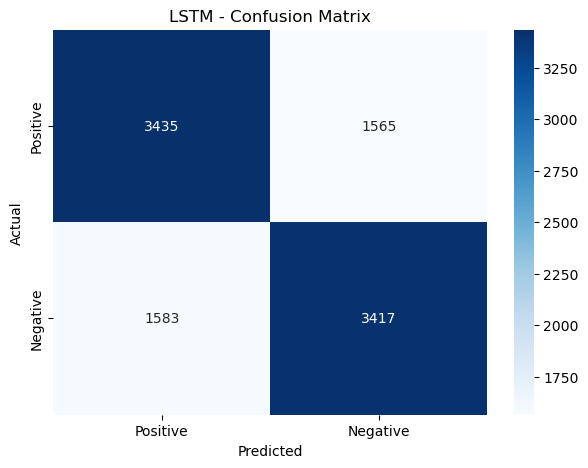

In [68]:
# Confusion Matrix - LSTM

plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, (model.predict(X_test) > 0.5).astype("int32"), labels=[1,0]), annot=True, fmt='d', cmap='Blues',
    xticklabels=["Positive","Negative"],
    yticklabels=["Positive","Negative"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM - Confusion Matrix")
plt.show()

Observation :

- The model is predicting almost everything as Positive.

- The LSTM model is biased toward predicting the Positive reviews leading to very poor performance on Negative reviews.

##### Developing, training and evaluating models like LogisticRegression, Naive Bayes, SVM and RandomForest models :


Logistic Regression
Accuracy: 0.5073
ROC-AUC: 0.5106

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.51      0.51      5000
           1       0.51      0.50      0.51      5000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



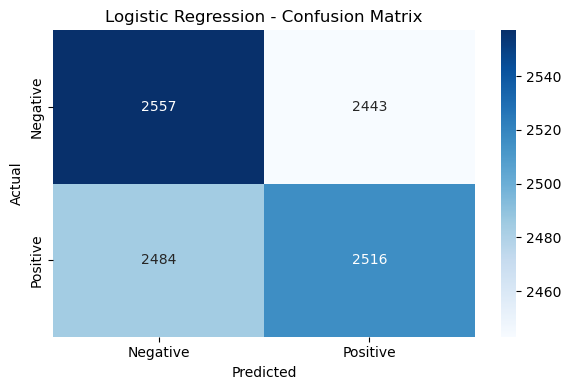


Naive Bayes
Accuracy: 0.5062
ROC-AUC: 0.5052

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.49      0.50      5000
           1       0.51      0.52      0.51      5000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



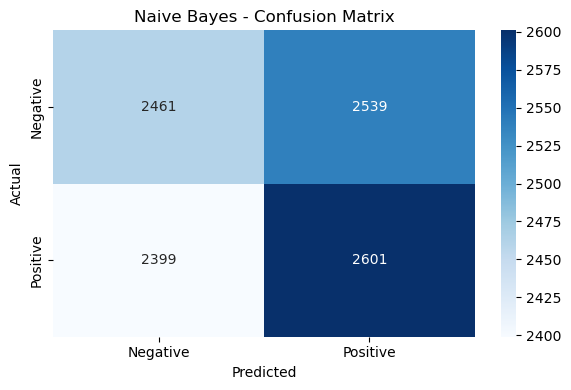


SVM
Accuracy: 0.5104
ROC-AUC: 0.5117

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.51      0.51      5000
           1       0.51      0.51      0.51      5000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



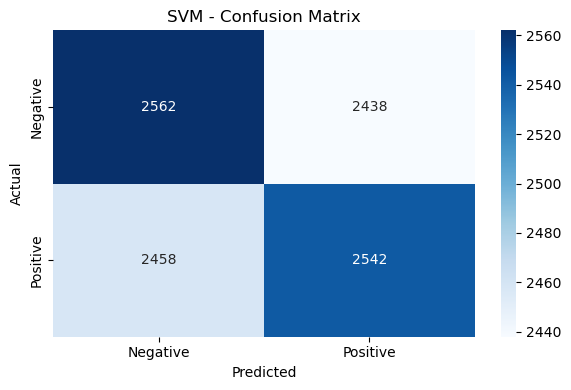


Random Forest
Accuracy: 0.4981
ROC-AUC: 0.4986

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.51      0.51      5000
           1       0.50      0.48      0.49      5000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



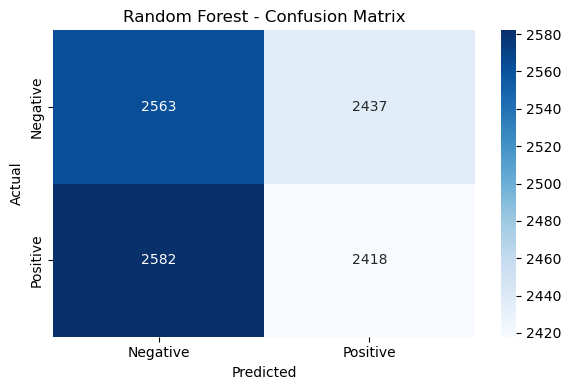

In [76]:
# Defining Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


# Training, Predicting and Evaluating Models

results = []

for name, model in models.items():
    model.fit(X_train_combined, y_train)
    y_pred = model.predict(X_test_combined)
    
    # ROC-AUC score (we will use predict_proba if available else decision score)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_combined)[:, 1]
    else:
        y_proba = model.decision_function(X_test_combined)
    roc_auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print("Accuracy:", round(acc, 4))
    print("ROC-AUC:", round(roc_auc, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Storing results
    results.append((name, acc, roc_auc))

    # Plotting using Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',xticklabels=["Negative","Positive"],
        yticklabels=["Negative","Positive"]
    )
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

##### Visualization of above four model for model accuracy comparison :

In [70]:
# Creating a Dataframe to show table comparison

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
results_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.5073,0.510649
1,Naive Bayes,0.5062,0.505218
2,SVM,0.5104,0.511703
3,Random Forest,0.4981,0.498589


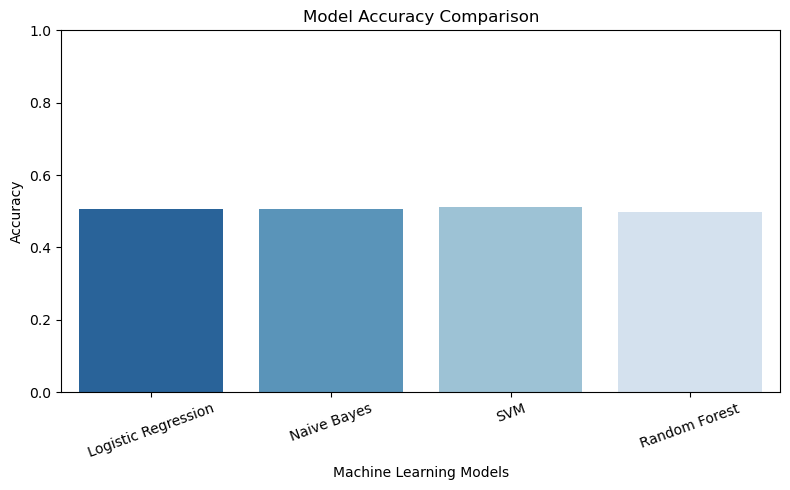

In [71]:
# Visualization

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="Blues_r")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Findings :

- The SVM model has highest accuracy among all four traditional models.

- The Logistic Regression amd Naive Bayes model is learning something small, but not strong enough.

- The Random Forest model does not work well on high-dimensional sparse text.

#### Model Deployment :

In [72]:
# Save Trained Model and Vectorizer using 'joblib' library

import joblib

# Train Logistic Regression again on combined features (if not already trained)
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train_combined, y_train)

# Save model and vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(lr_model, "logistic_regression_model.pkl")

print("Model and Vectorizer Saved Successfully!")

Model and Vectorizer Saved Successfully!


In [73]:
# Loading Model and Vectorizer

loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")
loaded_model = joblib.load("logistic_regression_model.pkl")

# Pre-Processing the text

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Extracting Numeric Text Features

def get_text_features(text):
    words = text.split()
    word_count = len(words)
    char_count = len(text)
    avg_word_length = np.mean([len(w) for w in words]) if word_count > 0 else 0
    return np.array([[word_count, char_count, avg_word_length]])

# Predicting Sentiment for New Review

def predict_sentiment(review):
    cleaned = preprocess_text(review)
    tfidf_vec = loaded_vectorizer.transform([cleaned])
    text_feat = get_text_features(cleaned)
    combined = hstack([tfidf_vec, text_feat])
    pred = loaded_model.predict(combined)[0]
    prob = loaded_model.predict_proba(combined)[0,1]

    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = round(prob if pred == 1 else 1 - prob, 3)
    return sentiment, confidence

#### Trying out the model for prediction :

In [74]:
# Getting user input

review = input("Enter a movie review:\n")
sentiment, confidence = predict_sentiment(review)
print("\nSentiment:", sentiment)
print("Confidence:", confidence)

Enter a movie review:
 The movie was really enjoyable. The performances were natural and the story felt meaningful.



Sentiment: Positive
Confidence: 0.53


In [75]:
review = input("Enter a movie review:\n")
sentiment, confidence = predict_sentiment(review)
print("\nSentiment:", sentiment)
print("Confidence:", confidence)

Enter a movie review:
 The film didn’t work for me. The pacing was slow and the characters were not interesting.



Sentiment: Negative
Confidence: 0.602


#### Conclusion :

- The traditional Logistic Regression model was successfully deployed and tested, and it was able to correctly predict the sentiment of new              movie reviews entered by the user.
- However, when comparing overall performance, the LSTM model achieved a higher test accuracy of around 68–69% showing that it was better at learning    the patterns in the review text.
- So, while the traditional model worked well for real-time prediction, the LSTM model can be considered the stronger performer overall based on         accuracy.

## Task 5 :

### Video Explanation Link

https://www.loom.com/share/7b42af68cae743f781b45c30f3b84d12